# 05 - Model Explainability (SHAP)

A credit-risk model that cannot be explained cannot be deployed — both regulators and credit officers need to know *why* a borrower is flagged as risky. This notebook uses SHAP (SHapley Additive exPlanations) to open up the champion XGBoost model: which features drive its predictions, in which direction, and how individual decisions are composed. SHAP values are additive and model-faithful, so they give an honest account of the model rather than a post-hoc rationalisation.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt


with open(f'../models/feature_list.txt') as f:
    selected_features = f.read().split()

champion = joblib.load(f'../models/champion_xgb_production.pkl')

# Explain on the validation set (sample for speed if large)
X_val = pd.read_parquet(f'../data/processed/X_val.parquet')[selected_features]
X_explain = X_val.sample(min(5000, len(X_val)), random_state=42)
print('Explaining on', X_explain.shape[0], 'loans')

Explaining on 5000 loans


## SHAP vs. Model Feature Importance

The feature importance results presented in **04_modelling** were based on XGBoost's built-in `feature_importances_`, which measure **gain**—the reduction in training loss attributable to each feature's splits. In contrast, SHAP measures the average contribution of each feature to the model's predictions on the validation sample. Put simply, gain explains **how the model was built**, while SHAP explains **how the model makes predictions**.

SHAP provides a more reliable view of real-world model behaviour because it is calculated on unseen validation data and is less sensitive to feature type. Gain can favour continuous variables with many potential split points, whereas SHAP evaluates the actual impact of each feature on predicted risk. SHAP also provides directionality, showing whether a feature increases or decreases default risk, and can explain individual loan predictions.

In practice, both methods identify the same core risk drivers, indicating a stable and consistent model. Differences tend to appear among lower-ranked features, where contributions are smaller and gain-based rankings are more susceptible to split-selection bias. For explaining predicted default risk and supporting lending decisions, SHAP therefore provides the more interpretable and defensible measure of feature importance.

### 1. Global importance — what drives default risk overall

The bar plot ranks features by mean absolute SHAP value (average impact on the prediction). The beeswarm plot adds direction and distribution: each dot is one loan, colour is the feature value (red = high, blue = low), and horizontal position is the push toward (right) or away from (left) predicted default.

In [2]:
# SHAP explains how each feature contributes to a prediction.
# Positive SHAP values increase predicted default risk, while negative values reduce it.
# TreeExplainer provides an efficient exact SHAP implementation for tree-based models such as XGBoost.
explainer = shap.TreeExplainer(champion)
shap_values = explainer.shap_values(X_explain)

print(f'SHAP values shape: {np.array(shap_values).shape}')

SHAP values shape: (5000, 15)


fico_orig            0.319627
loan_to_income       0.231489
dti                  0.158184
loan_amnt            0.109032
home_ownership       0.093275
purpose_risk_tier    0.084830
vintage_year         0.061016
open_acc_band        0.042935
revol_util           0.042264
log_annual_inc       0.038041
employment_years     0.027161
vintage_quarter      0.017702
pub_rec_flag         0.015240
delinq_flag          0.003365
short_tenure_flag    0.002541
dtype: float32



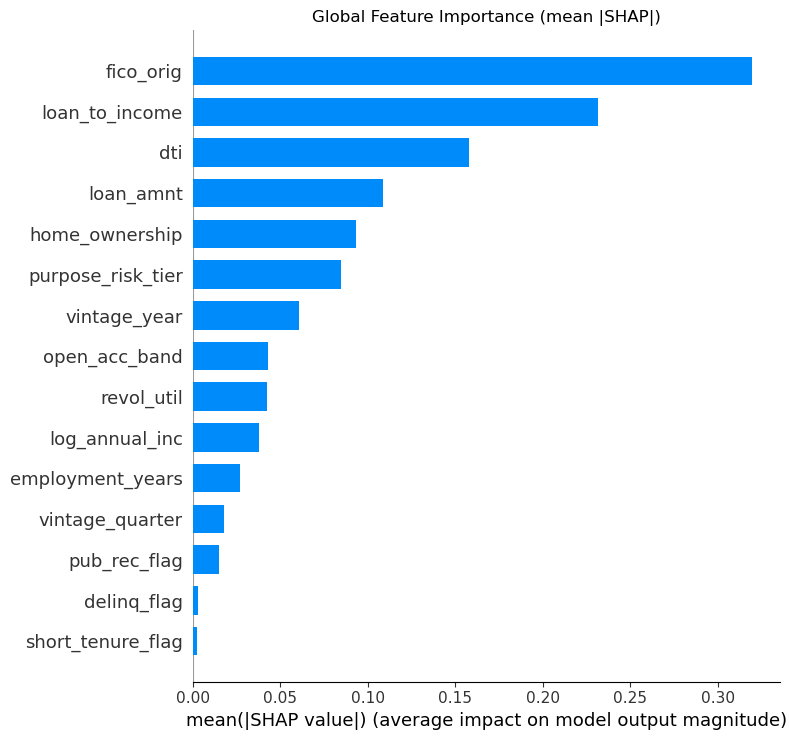

In [3]:
# Mean |SHAP| bar plot
shap_importance = pd.Series( np.abs(shap_values).mean(axis=0), index=X_explain.columns).sort_values(ascending=False)
print(shap_importance.head(15))
print()

shap.summary_plot(shap_values, X_explain, plot_type='bar', show=False, max_display=15)
plt.title('Global Feature Importance (mean |SHAP|)') 
plt.tight_layout()
plt.savefig('../report/figures/shap_01_bar.png', bbox_inches='tight')
plt.show()

#### Global SHAP Feature Importance

The SHAP results show that the model is driven primarily by **credit quality and affordability**. **FICO score** is the strongest predictor of default risk, followed by **loan-to-income ratio**, **debt-to-income ratio**, and **loan amount**, highlighting the importance of borrower creditworthiness and repayment capacity.

Engineered features such as **home ownership**, **purpose risk tier**, and **vintage year** also contribute meaningfully, indicating that borrower characteristics and origination-period conditions influence default outcomes. Lower-ranked variables, including **public records**, **delinquency flags**, and **short tenure indicators**, add relatively little incremental predictive value once the major risk drivers are considered.

Overall, the SHAP ranking confirms that the model's predictions are based on intuitive and economically meaningful drivers of credit risk.

### 2. SHAP Direction of Effect

While the SHAP importance ranking identifies which features matter most, the beeswarm plot shows how those features influence predicted default risk across individual loans. Each point represents a borrower, with features pushing risk either higher (right) or lower (left). Red points indicate higher feature values, while blue points indicate lower values.

The plot confirms that the model's strongest risk drivers not only rank highly in importance but also behave in directions consistent with credit-risk theory. Higher leverage and indebtedness generally increase predicted risk, while stronger credit quality and borrower affordability reduce it. This provides a portfolio-level view of how the champion model translates borrower characteristics into risk assessments.

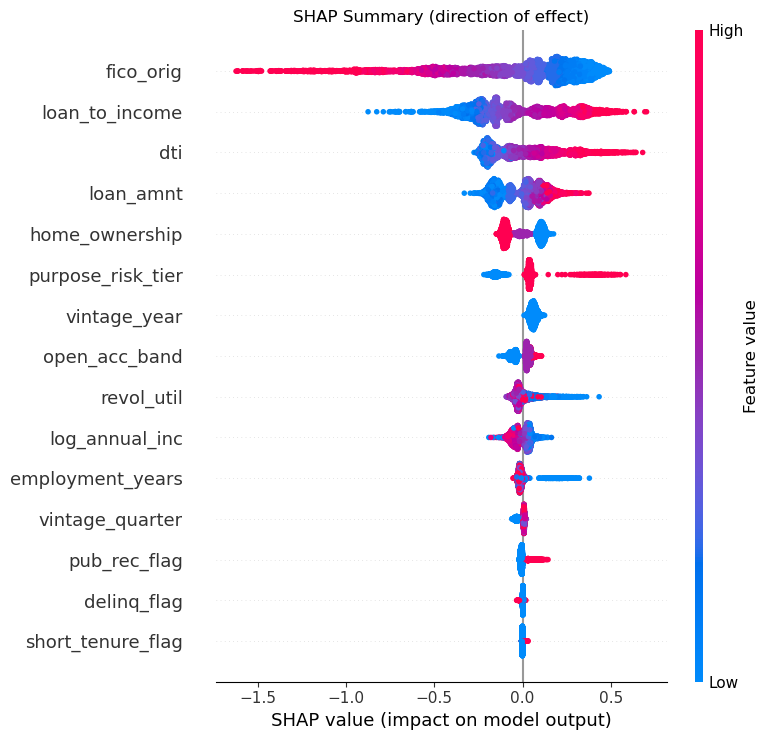

In [4]:
# Beeswarm — direction and spread of each feature's effect
shap.summary_plot(shap_values, X_explain, show=False, max_display=15)
plt.title('SHAP Summary (direction of effect)') 
plt.tight_layout()
plt.savefig('../report/figures/shap_02_beeswarm.png', bbox_inches='tight')
plt.show()

#### SHAP Beeswarm Plot (Direction of Effect)

While the previous SHAP importance chart identified **which features matter most**, the beeswarm plot explains **how those features influence predicted default risk**. Each point represents a loan, with features pushing risk either higher (right) or lower (left). Red points correspond to higher feature values, while blue points represent lower values.

The direction of the effects is consistent with the global importance findings. **Higher loan-to-income ratios, debt-to-income ratios, loan amounts, and riskier loan purposes** generally push predictions toward higher default risk. Conversely, **stronger FICO scores, higher incomes, and longer employment histories** tend to reduce predicted risk. The wide spread of SHAP values for FICO score and affordability measures further reinforces their role as the model's primary risk drivers.

Together, the importance ranking and beeswarm analysis show that the model is not only relying on economically meaningful variables but is also using them in directions consistent with established credit-risk theory.

### 3. Dependence – How the Strongest Risk Driver Behaves

While the SHAP importance ranking identifies which features matter most, a dependence plot shows how a feature's contribution changes across its range. For the most important feature, FICO score, the plot reveals a clear relationship: higher credit quality consistently reduces predicted default risk. This confirms that the model has learned an intuitive and economically meaningful credit-risk pattern.

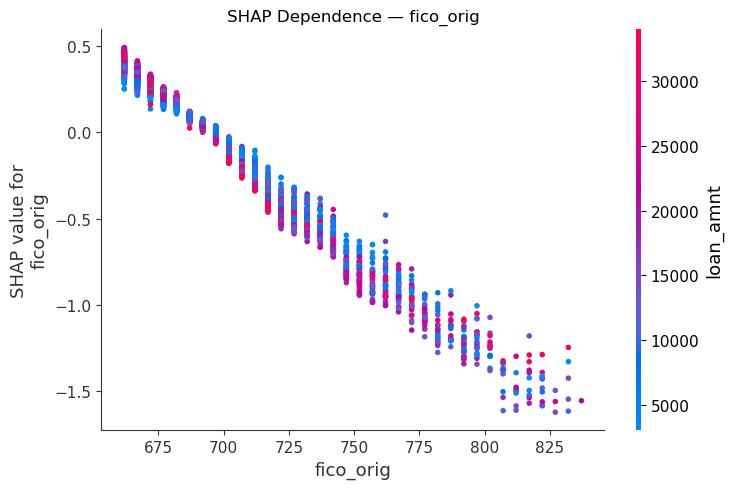

Most influential feature: fico_orig


In [5]:
top_feature = pd.Series(np.abs(shap_values).mean(0), index=selected_features).idxmax()
shap.dependence_plot(top_feature, shap_values, X_explain, show=False)
plt.title(f'SHAP Dependence — {top_feature}')
plt.tight_layout()
plt.savefig(f'../report/figures/shap_03_dependence_{top_feature}.png', dpi=150, bbox_inches='tight') 
plt.show()
print('Most influential feature:', top_feature)

#### SHAP Dependence Plot – FICO Score

While the beeswarm plot showed that **FICO score is the model's most important risk driver**, the dependence plot reveals the nature of that relationship. The strong downward trend indicates that as **FICO scores increase, predicted default risk consistently decreases**. Lower-credit-quality borrowers (lower FICO scores) contribute positively to risk predictions, while higher-credit-quality borrowers contribute increasingly negative SHAP values, reducing predicted risk.

The relationship is smooth and nearly monotonic, suggesting that the model has learned a stable and intuitive credit-risk pattern rather than relying on isolated thresholds. The colouring by **loan amount** shows only modest interaction effects, indicating that FICO score remains a dominant predictor across different loan sizes.

This result reinforces the earlier SHAP findings and aligns with established lending theory: borrowers with stronger credit histories are consistently associated with lower default risk.

## 4. Explaining an Individual Lending Decision

For a credit officer, the most useful output is a per-loan explanation. The waterfall below decomposes one borrower's predicted risk into the exact feature contributions that produced it — the kind of transparent, auditable rationale required for an adverse-action notice.

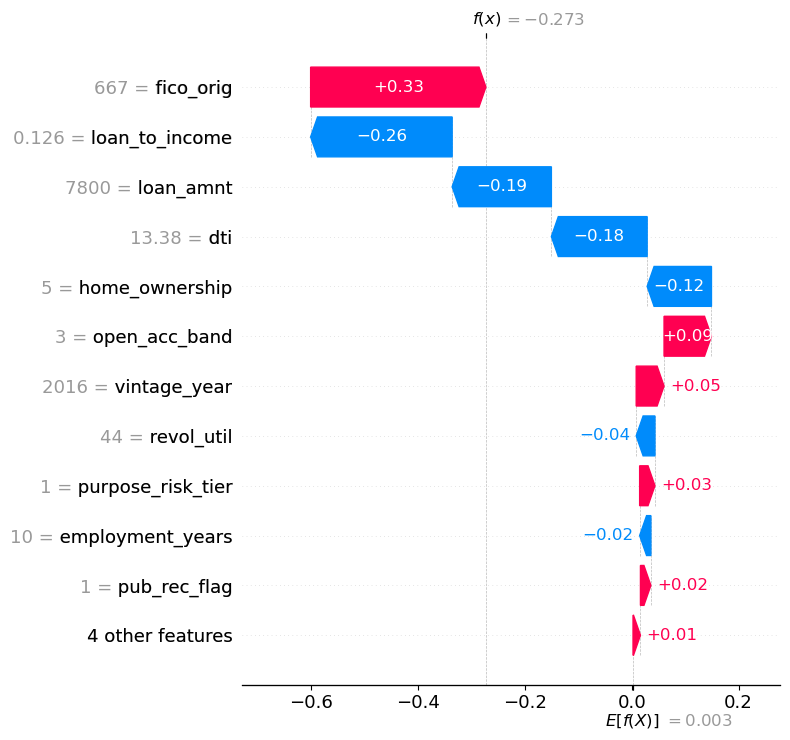

In [6]:
# Select the loan to explain
i = 0

# Explain a single loan prediction by decomposing the model output into
# feature-level contributions. Positive SHAP values increase predicted risk,
# negative SHAP values reduce it, and the contributions sum from the
# portfolio-average prediction (base value) to the loan's final prediction.
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[i],
        base_values=explainer.expected_value,
        data=X_explain.iloc[i],
        feature_names=selected_features
    ),
    max_display=12,
    show=False
)

plt.tight_layout()
plt.savefig(f'../report/figures/shap_04_waterfall.png', bbox_inches='tight') 
plt.show()

#### Local SHAP Explanation – Individual Loan

The preceding SHAP analyses explained the model at the portfolio level by identifying the most important risk drivers and showing how they generally influence predicted default risk. The waterfall plot extends this analysis to a **single borrower**, providing a transparent breakdown of how the model arrived at an individual lending decision.

Each row shows both the borrower's actual feature value and its contribution to the prediction. For example, **667 = fico_orig** indicates that the borrower has a FICO score of 667, while the corresponding SHAP value quantifies how much that characteristic influenced the model output. This allows the prediction to be traced directly to the borrower's underlying profile rather than being treated as a black-box score.

For this borrower, the strongest risk-reducing factors are **loan-to-income ratio**, **loan amount**, **debt-to-income ratio**, and **home ownership**, all of which lower the predicted risk. These favourable characteristics outweigh the risk-increasing effects of **FICO score**, **open account band**, **vintage year**, and several smaller contributors, resulting in the final prediction shown as **f(x)**.

The plot begins at the portfolio-average prediction, **E[f(X)]**, and sequentially adds the contribution of each feature to reach the borrower's final score. Features shown in red increase predicted risk, while features shown in blue reduce it. This illustrates an important principle of credit-risk modelling: lending decisions are rarely driven by a single variable but instead reflect the combined effect of multiple borrower, loan, and macroeconomic characteristics.

From a practical perspective, this level of transparency supports model governance, regulatory explainability, and adverse-action reporting by clearly identifying the factors that most influenced an individual prediction. Together with the global SHAP analyses, the waterfall plot demonstrates that the model's portfolio-level risk drivers are consistently reflected in individual lending decisions.

## Summary
SHAP confirms that the champion model learns economically meaningful credit-risk relationships from leakage-free origination data. The dominant drivers of predicted default risk are borrower credit quality, affordability, leverage, loan characteristics, and origination-vintage effects, with FICO score, loan-to-income ratio, debt-to-income ratio, and loan amount emerging as the strongest predictors. The consistency between the global importance rankings, directional effects, dependence analysis, and loan-level waterfall explanations demonstrates that the model's predictions are transparent, traceable, and aligned with established credit-risk principles. Together, these results provide a defensible link between portfolio-level risk drivers and individual lending decisions while supporting model governance and IFRS 9 ECL applications.